Image size : 1200 * 1800 * 3


(-0.5, 1799.5, 1199.5, -0.5)

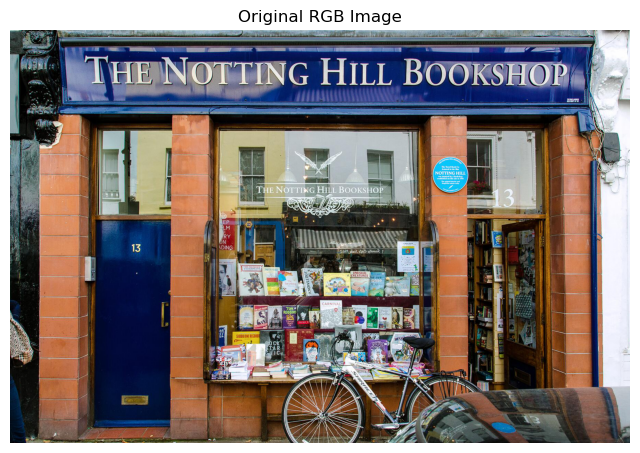

In [ ]:
S

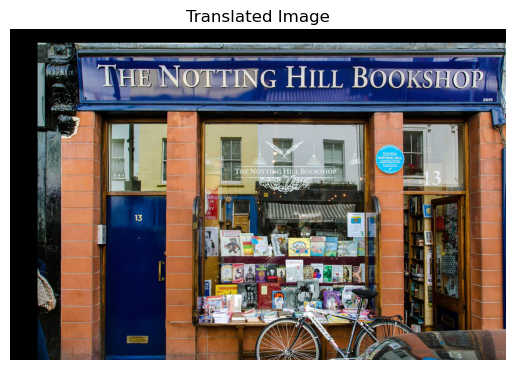

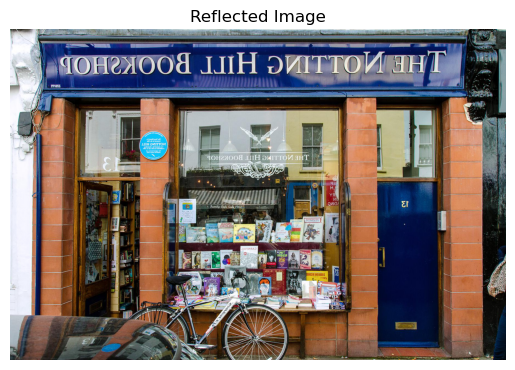

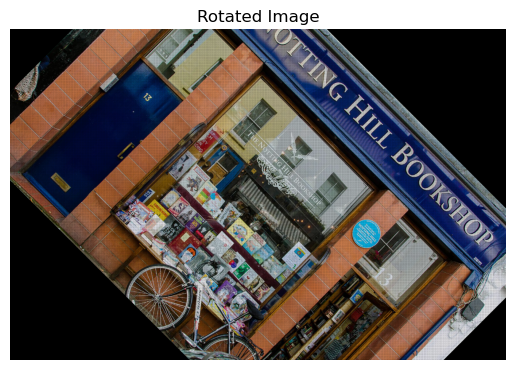

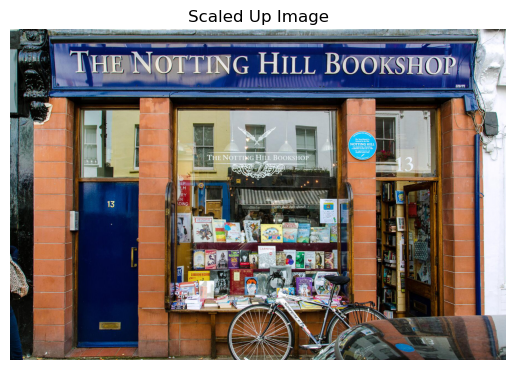

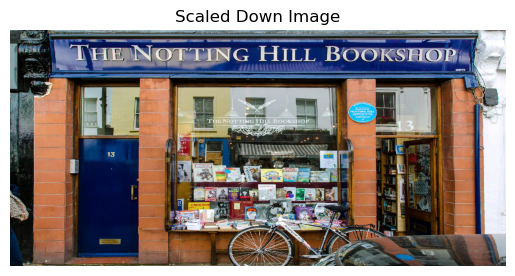

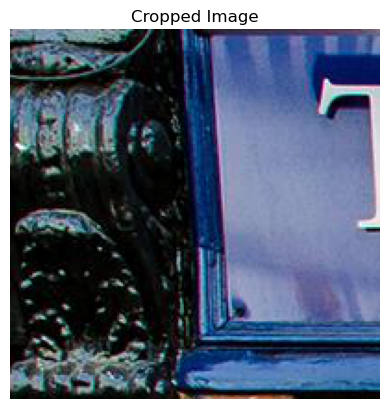

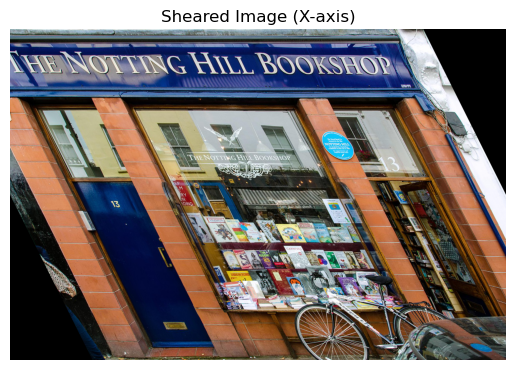

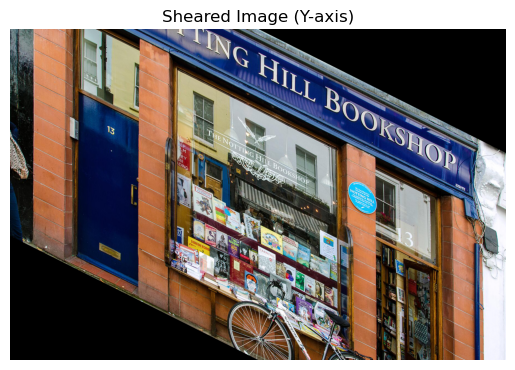

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def display_image(img, title="Image"):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Load an image
image = cv2.imread("C:/Users/student/Documents/Computer Vision 2023510051/nottinghillbookshop.jpg")
height, width, channels = image.shape

# 1. Image Translation (manually shifting pixel positions)
def translate_image(image, tx, ty):
    translated = np.zeros_like(image)
    for i in range(height):
        for j in range(width):
            if 0 <= i + ty < height and 0 <= j + tx < width:
                translated[i + ty, j + tx] = image[i, j]
    return translated

# 2. Image Reflection (Flipping manually)
def reflect_image(image, axis=0):
    reflected = np.zeros_like(image)
    if axis == 0:  # Flip along the x-axis (horizontal flip)
        for i in range(height):
            for j in range(width):
                reflected[height - 1 - i, j] = image[i, j]
    elif axis == 1:  # Flip along the y-axis (vertical flip)
        for i in range(height):
            for j in range(width):
                reflected[i, width - 1 - j] = image[i, j]
    else:  # Flip both axes
        for i in range(height):
            for j in range(width):
                reflected[height - 1 - i, width - 1 - j] = image[i, j]
    return reflected

# 3. Image Rotation (without using OpenCV rotation function)
def rotate_image(image, angle):
    angle_rad = np.radians(angle)
    center_x, center_y = width // 2, height // 2
    rotated = np.zeros_like(image)

    for i in range(height):
        for j in range(width):
            # Calculate new coordinates
            x = j - center_x
            y = i - center_y
            new_x = int(np.round(center_x + x * np.cos(angle_rad) - y * np.sin(angle_rad)))
            new_y = int(np.round(center_y + x * np.sin(angle_rad) + y * np.cos(angle_rad)))

            # Check if new coordinates are within image bounds
            if 0 <= new_x < width and 0 <= new_y < height:
                rotated[new_y, new_x] = image[i, j]

    return rotated

# 4. Image Scaling (Resizing manually)
def scale_image(image, scale_x, scale_y):
    new_width = int(width * scale_x)
    new_height = int(height * scale_y)
    scaled = np.zeros((new_height, new_width, channels), dtype=np.uint8)

    for i in range(new_height):
        for j in range(new_width):
            orig_x = int(j / scale_x)
            orig_y = int(i / scale_y)
            if orig_x < width and orig_y < height:
                scaled[i, j] = image[orig_y, orig_x]
    return scaled

# 5. Image Cropping (manually selecting the region)
def crop_image(image, start_x, start_y, crop_width, crop_height):
    cropped = image[start_y:start_y+crop_height, start_x:start_x+crop_width]
    return cropped

# 6. Shearing in x-axis (manual implementation)
def shear_x(image, shear_factor):
    sheared = np.zeros_like(image)
    for i in range(height):
        for j in range(width):
            new_x = int(j + shear_factor * (i - height // 2))
            if 0 <= new_x < width:
                sheared[i, new_x] = image[i, j]
    return sheared

# 7. Shearing in y-axis (manual implementation)
def shear_y(image, shear_factor):
    sheared = np.zeros_like(image)
    for i in range(height):
        for j in range(width):
            new_y = int(i + shear_factor * (j - width // 2))
            if 0 <= new_y < height:
                sheared[new_y, j] = image[i, j]
    return sheared

# Test all transformations
translated_image = translate_image(image, 100, 50)
reflected_image = reflect_image(image, 1)  # Horizontal reflection
rotated_image = rotate_image(image, 45)  # Rotate 45 degrees
scaledup_image = scale_image(image, 1.5, 1.5)  # Scale by 1.5x
scaleddown_image = scale_image(image, 0.7, 0.5)
cropped_image = crop_image(image, 50, 50, 200, 200)  # Crop region (50, 50) to (250, 250)
sheared_x_image = shear_x(image, 0.5)  # Shear in x-axis
sheared_y_image = shear_y(image, 0.5)  # Shear in y-axis

# Display transformed images
display_image(translated_image, "Translated Image")
display_image(reflected_image, "Reflected Image")
display_image(rotated_image, "Rotated Image")
display_image(scaledup_image, "Scaled Up Image")
display_image(scaleddown_image, "Scaled Down Image")
display_image(cropped_image, "Cropped Image")
display_image(sheared_x_image, "Sheared Image (X-axis)")
display_image(sheared_y_image, "Sheared Image (Y-axis)")


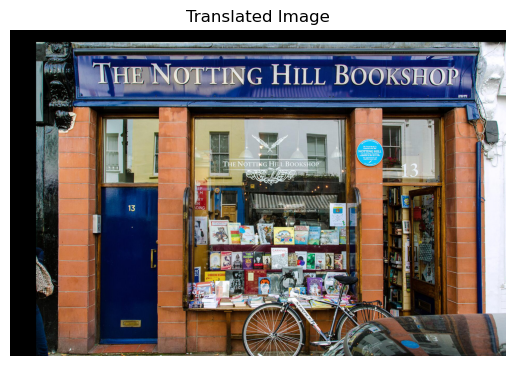

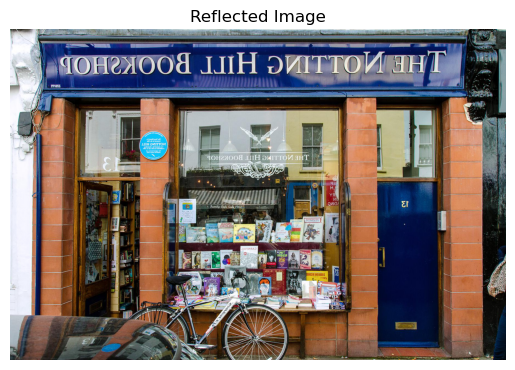

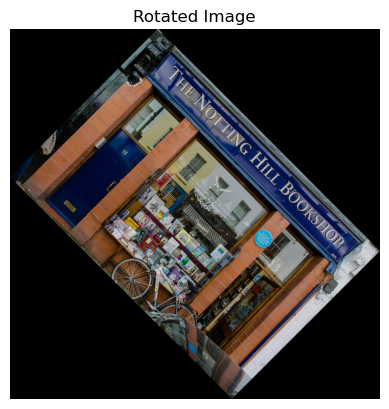

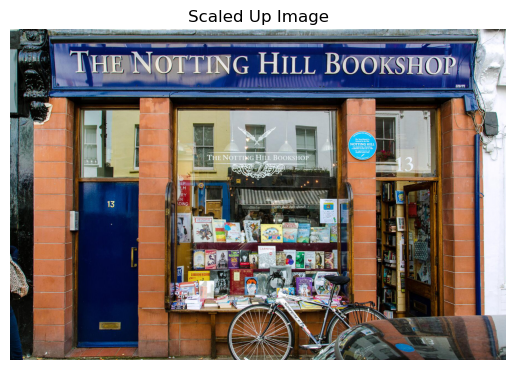

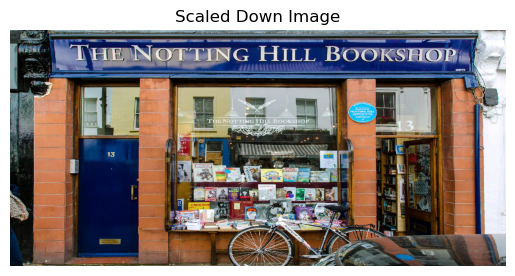

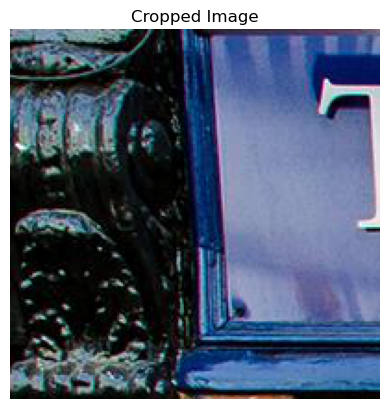

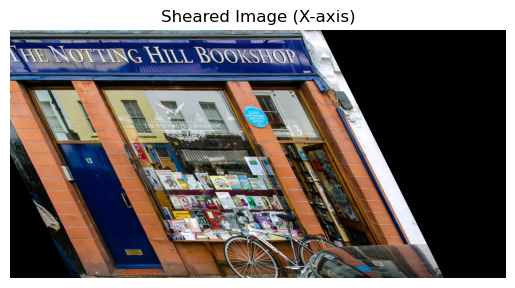

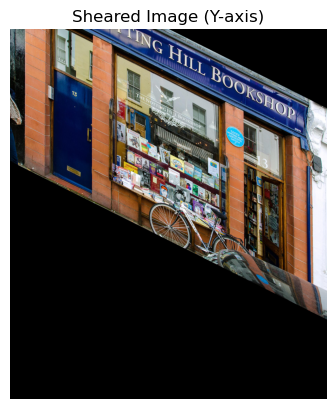

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def display_image(img, title="Image"):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Load an image
image = cv2.imread("C:/Users/student/Documents/Computer Vision 2023510051/nottinghillbookshop.jpg")
height, width, channels = image.shape

# 1. Image Translation (shifting pixel positions with a larger canvas)
def translate_image(image, tx, ty):
    new_height, new_width = height + abs(ty), width + abs(tx)
    translated = np.zeros((new_height, new_width, channels), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            translated[i + ty, j + tx] = image[i, j]
    return translated

# 2. Image Reflection (Horizontal, Vertical, or Both)
def reflect_image(image, axis=0):
    reflected = np.zeros_like(image)
    if axis == 0:  # Flip horizontally
        reflected[:] = image[::-1, :]
    elif axis == 1:  # Flip vertically
        reflected[:] = image[:, ::-1]
    else:  # Flip both axes
        reflected[:] = image[::-1, ::-1]
    return reflected

# 3. Image Rotation (Preserving full image size)
def rotate_image(image, angle):
    angle_rad = np.radians(angle)

    # Compute the new bounding box size
    new_width = int(abs(height * np.sin(angle_rad)) + abs(width * np.cos(angle_rad)))
    new_height = int(abs(height * np.cos(angle_rad)) + abs(width * np.sin(angle_rad)))

    rotated = np.zeros((new_height, new_width, channels), dtype=np.uint8)
    center_x, center_y = width // 2, height // 2
    new_center_x, new_center_y = new_width // 2, new_height // 2

    for i in range(height):
        for j in range(width):
            x = j - center_x
            y = i - center_y
            new_x = int(new_center_x + x * np.cos(angle_rad) - y * np.sin(angle_rad))
            new_y = int(new_center_y + x * np.sin(angle_rad) + y * np.cos(angle_rad))
            if 0 <= new_x < new_width and 0 <= new_y < new_height:
                rotated[new_y, new_x] = image[i, j]

    return rotated

# 4. Image Scaling (No Pixel Loss)
def scale_image(image, scale_x, scale_y):
    new_width = int(width * scale_x)
    new_height = int(height * scale_y)
    scaled = np.zeros((new_height, new_width, channels), dtype=np.uint8)

    for i in range(new_height):
        for j in range(new_width):
            orig_x = int(j / scale_x)
            orig_y = int(i / scale_y)
            if orig_x < width and orig_y < height:
                scaled[i, j] = image[orig_y, orig_x]
    return scaled

# 5. Image Cropping (Ensure valid region)
def crop_image(image, start_x, start_y, crop_width, crop_height):
    end_x = min(start_x + crop_width, image.shape[1])
    end_y = min(start_y + crop_height, image.shape[0])
    return image[start_y:end_y, start_x:end_x]

# 6. Shearing in x-axis (Avoiding Pixel Loss)
def shear_x(image, shear_factor):
    new_width = width + int(shear_factor * height)
    sheared = np.zeros((height, new_width, channels), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            new_x = int(j + shear_factor * (i - height // 2))
            if 0 <= new_x < new_width:
                sheared[i, new_x] = image[i, j]
    return sheared

# 7. Shearing in y-axis (Avoiding Pixel Loss)
def shear_y(image, shear_factor):
    new_height = height + int(shear_factor * width)
    sheared = np.zeros((new_height, width, channels), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            new_y = int(i + shear_factor * (j - width // 2))
            if 0 <= new_y < new_height:
                sheared[new_y, j] = image[i, j]
    return sheared

# Test all transformations (No Pixel Loss)
translated_image = translate_image(image, 100, 50)
reflected_image = reflect_image(image, 1)  # Horizontal reflection
rotated_image = rotate_image(image, 45)  # Rotate 45 degrees (No pixel loss)
scaledup_image = scale_image(image, 1.5, 1.5)  # Scale up by 1.5x (No pixel loss)
scaleddown_image = scale_image(image, 0.7, 0.5)  # Scale down
cropped_image = crop_image(image, 50, 50, 200, 200)  # Crop region (50, 50) to (250, 250)
sheared_x_image = shear_x(image, 0.5)  # Shear in x-axis
sheared_y_image = shear_y(image, 0.5)  # Shear in y-axis

# Display Transformed Images
display_image(translated_image, "Translated Image")
display_image(reflected_image, "Reflected Image")
display_image(rotated_image, "Rotated Image")
display_image(scaledup_image, "Scaled Up Image")
display_image(scaleddown_image, "Scaled Down Image")
display_image(cropped_image, "Cropped Image")
display_image(sheared_x_image, "Sheared Image (X-axis)")
display_image(sheared_y_image, "Sheared Image (Y-axis)")


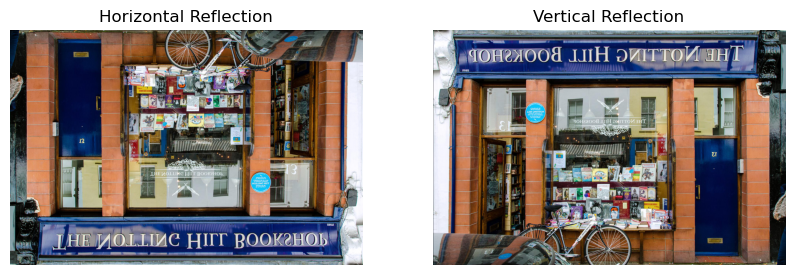

In [ ]:
import cv2
import numpy as np

# Load the image
image = cv2.imread("C:/Users/student/Documents/Computer Vision 2023510051/nottinghillbookshop.jpg")
h, w, c = image.shape

# Horizontal Reflection Matrix (Reflect across x-axis)
T_horizontal = np.float32([[1, 0, 0], [0, -1, h], [0, 0, 1]])

# Vertical Reflection Matrix (Reflect across y-axis)
T_vertical = np.float32([[-1, 0, w], [0, 1, 0], [0, 0, 1]])

# Create a blank canvas for the reflected image
reflected_image_horizontal = np.zeros_like(image)
reflected_image_vertical = np.zeros_like(image)

# Apply the transformations using matrix multiplication
for y in range(h):
    for x in range(w):
        # Homogeneous coordinates for each pixel
        pixel_coord = np.array([x, y, 1])

        # Apply reflection transformation
        new_coord_horizontal = T_horizontal @ pixel_coord
        new_coord_vertical = T_vertical @ pixel_coord

        new_x_h, new_y_h, _ = new_coord_horizontal.astype(int)
        new_x_v, new_y_v, _ = new_coord_vertical.astype(int)

        # Check if the new coordinates are within bounds
        if 0 <= new_x_h < w and 0 <= new_y_h < h:
            reflected_image_horizontal[new_y_h, new_x_h] = rgb_image[y, x]
        if 0 <= new_x_v < w and 0 <= new_y_v < h:
            reflected_image_vertical[new_y_v, new_x_v] = rgb_image[y, x]


plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(reflected_image_horizontal)
plt.title("Horizontal Reflection")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reflected_image_vertical)
plt.title("Vertical Reflection")
plt.axis("off")

plt.show()